In [ ]:

from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("Yelp Analysis") \
    .config("spark.sql.catalogImplementation", "hive") \
    .enableHiveSupport() \
    .getOrCreate()

spark.sql("SHOW DATABASES").show()

+---------+
|namespace|
+---------+
|  default|
|  yelp_db|
+---------+



In [ ]:

spark.sql("USE yelp_db")
spark.sql("SHOW TABLES").show(50, False)

+---------+-------------+-----------+
|namespace|tableName    |isTemporary|
+---------+-------------+-----------+
|yelp_db  |json_business|false      |
|yelp_db  |business     |false      |
|yelp_db  |review       |false      |
|yelp_db  |json_review  |false      |
|yelp_db  |json_user    |false      |
|yelp_db  |users        |false      |
|yelp_db  |json_checkin |false      |
|yelp_db  |checkin      |false      |
|yelp_db  |json_tip     |false      |
|yelp_db  |tip          |false      |
+---------+-------------+-----------+



QUESTION 1: Top 20 Most Common Merchants

RESULTS:
                 name  location_count
            Starbucks             724
           McDonald's             703
              Dunkin'             510
               Subway             459
            Taco Bell             365
         CVS Pharmacy             345
            Walgreens             341
          Burger King             338
              Wendy's             331
                 Wawa             307
       Domino's Pizza             295
        The UPS Store             281
            Pizza Hut             272
Enterprise Rent-A-Car             232
    Papa John's Pizza             196
          Great Clips             185
         Jimmy John's             175
       US Post Office             174
                  KFC             171
          Chick-fil-A             162


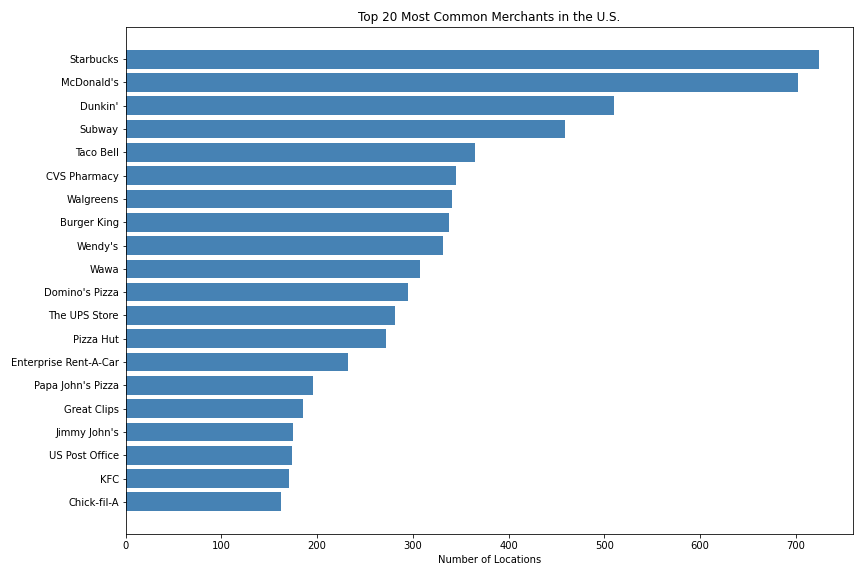

In [ ]:
import matplotlib.pyplot as plt

# QUESTION 1: Top 20 Most Common Merchants
print("=" * 60)
print("QUESTION 1: Top 20 Most Common Merchants")
print("=" * 60)

result1 = spark.sql("""
    SELECT name, COUNT(*) as location_count
    FROM business
    GROUP BY name
    ORDER BY location_count DESC
    LIMIT 20
""").toPandas()

print("\nRESULTS:")
print(result1.to_string(index=False))

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(result1['name'], result1['location_count'], color='steelblue')
plt.xlabel('Number of Locations')
plt.title('Top 20 Most Common Merchants in the U.S.')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

QUESTION 2: Top 10 Cities with Most Merchants

RESULTS:
         city  merchant_count
 Philadelphia           14569
       Tucson            9250
        Tampa            9050
 Indianapolis            7540
    Nashville            6971
  New Orleans            6209
         Reno            5935
     Edmonton            5054
  Saint Louis            4827
Santa Barbara            3829


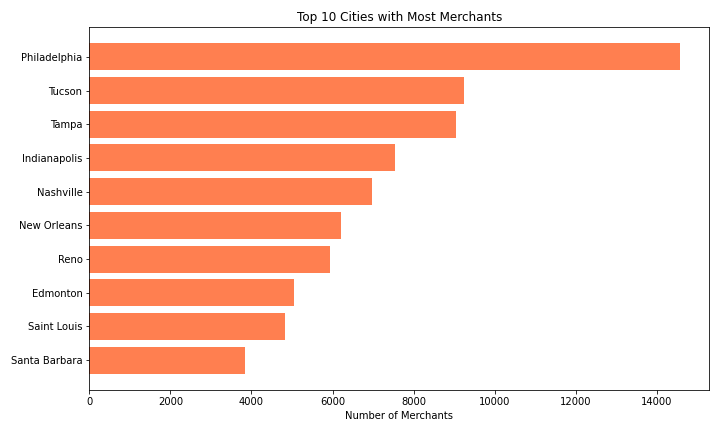

In [ ]:
import matplotlib.pyplot as plt

# QUESTION 2: Top 10 Cities with Most Merchants
print("=" * 60)
print("QUESTION 2: Top 10 Cities with Most Merchants")
print("=" * 60)

result2 = spark.sql("""
    SELECT city, COUNT(*) as merchant_count
    FROM business
    WHERE city IS NOT NULL AND city != ''
    GROUP BY city
    ORDER BY merchant_count DESC
    LIMIT 10
""").toPandas()

print("\nRESULTS:")
print(result2.to_string(index=False))

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(result2['city'], result2['merchant_count'], color='coral')
plt.xlabel('Number of Merchants')
plt.title('Top 10 Cities with Most Merchants')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

QUESTION 3: Top 5 States with Most Merchants

RESULTS:
state  merchant_count
   PA           34039
   FL           26330
   TN           12056
   IN           11247
   MO           10913


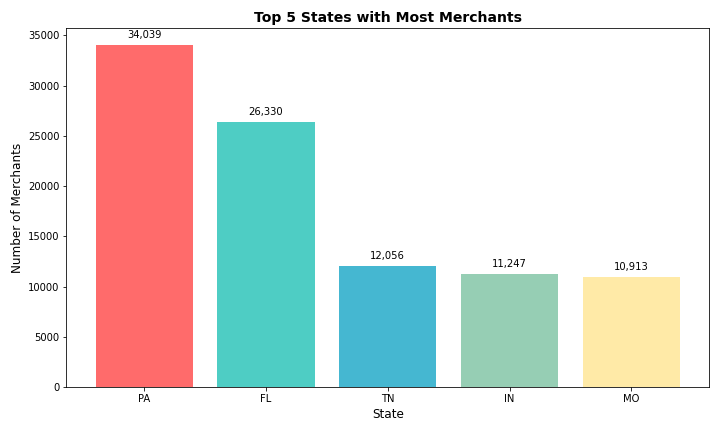

In [ ]:
import matplotlib.pyplot as plt

# QUESTION 3: Top 5 States with Most Merchants
print("=" * 60)
print("QUESTION 3: Top 5 States with Most Merchants")
print("=" * 60)

result3 = spark.sql("""
    SELECT state, COUNT(*) as merchant_count
    FROM business
    WHERE state IS NOT NULL AND state != ''
    GROUP BY state
    ORDER BY merchant_count DESC
    LIMIT 5
""").toPandas()

print("\nRESULTS:")
print(result3.to_string(index=False))

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(result3['state'], result3['merchant_count'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Merchants', fontsize=12)
plt.title('Top 5 States with Most Merchants', fontsize=14, fontweight='bold')

# Add value labels on top of bars
for bar, count in zip(bars, result3['merchant_count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

QUESTION 4: Top 20 Most Common Merchants and Their Average Ratings

RESULTS:
                 name  location_count  avg_rating
            Starbucks             724        3.13
           McDonald's             703        1.86
              Dunkin'             510        2.30
               Subway             459        2.59
            Taco Bell             365        2.15
         CVS Pharmacy             345        2.46
            Walgreens             341        2.62
          Burger King             338        2.03
              Wendy's             331        2.02
                 Wawa             307        3.32
       Domino's Pizza             295        2.28
        The UPS Store             281        3.22
            Pizza Hut             272        2.03
Enterprise Rent-A-Car             232        3.28
    Papa John's Pizza             196        2.41
          Great Clips             185        2.90
         Jimmy John's             175        2.87
       US Post Office  

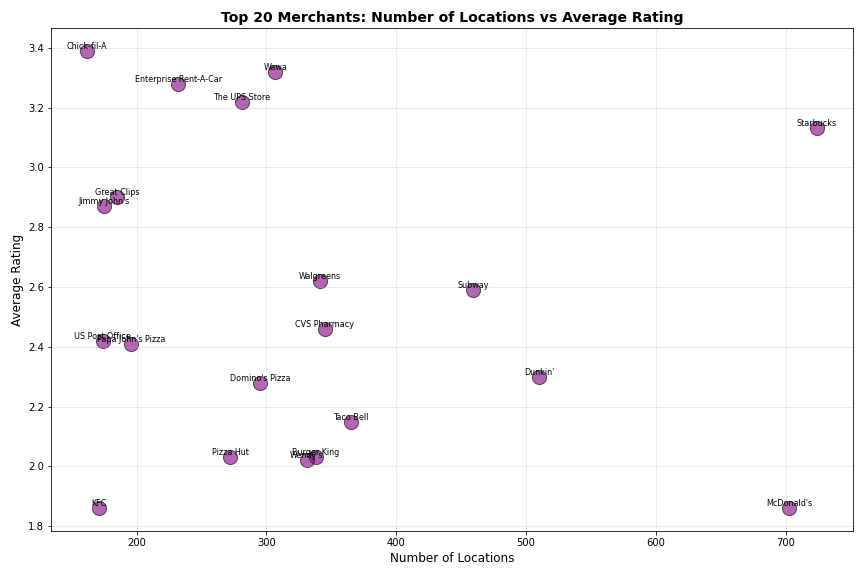

In [ ]:
import matplotlib.pyplot as plt

# QUESTION 4: Top 20 Most Common Merchants with Average Ratings
print("=" * 60)
print("QUESTION 4: Top 20 Most Common Merchants and Their Average Ratings")
print("=" * 60)

result4 = spark.sql("""
    SELECT name, 
           COUNT(*) as location_count,
           ROUND(AVG(stars), 2) as avg_rating
    FROM business
    GROUP BY name
    ORDER BY location_count DESC
    LIMIT 20
""").toPandas()

print("\nRESULTS:")
print(result4[['name', 'location_count', 'avg_rating']].to_string(index=False))

# Create scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(result4['location_count'], result4['avg_rating'], s=200, alpha=0.6, color='purple', edgecolors='black')

# Add labels for each point
for i, row in result4.iterrows():
    plt.annotate(row['name'], (row['location_count'], row['avg_rating']), 
                 fontsize=8, ha='center', va='bottom')

plt.xlabel('Number of Locations', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.title('Top 20 Merchants: Number of Locations vs Average Rating', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Add insight
print("\nINSIGHT:")
print(f"Highest rated: {result4.loc[result4['avg_rating'].idxmax(), 'name']} with {result4['avg_rating'].max()} stars")
print(f"Lowest rated: {result4.loc[result4['avg_rating'].idxmin(), 'name']} with {result4['avg_rating'].min()} stars")

QUESTION 5: Count the Number of Different Categories

RESULT: 83,160 unique category combinations


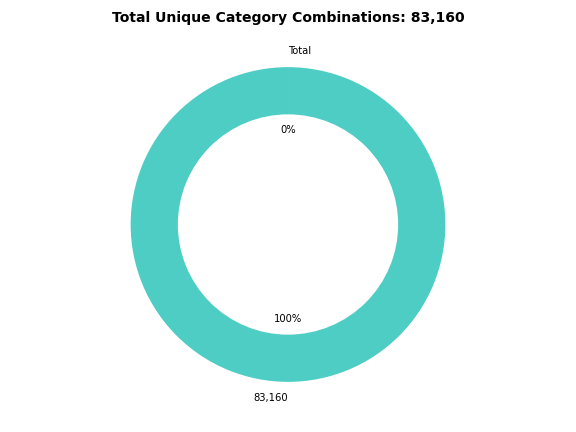

In [ ]:

import matplotlib.pyplot as plt

# QUESTION 5: Count the number of different categories
print("=" * 60)
print("QUESTION 5: Count the Number of Different Categories")
print("=" * 60)

result5 = spark.sql("""
    SELECT COUNT(DISTINCT categories) as unique_category_count
    FROM business
    WHERE categories IS NOT NULL AND categories != ''
""").toPandas()

category_count = result5['unique_category_count'].iloc[0]
print(f"\nRESULT: {category_count:,} unique category combinations")

# Create a simple donut chart to show the number
plt.figure(figsize=(8, 6))
plt.pie([category_count, 1], labels=[f'{category_count:,}', 'Total'], 
        autopct='%1.0f%%', colors=['#4ECDC4', '#E0E0E0'], startangle=90)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title(f'Total Unique Category Combinations: {category_count:,}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nINSIGHT: There are 83,160 different ways businesses categorize themselves.")

QUESTION 6: Top 10 Most Frequent Categories and Their Count

RESULTS:
                categories  business_count
Beauty & Spas, Nail Salons            1012
        Restaurants, Pizza             935
Nail Salons, Beauty & Spas             934
        Pizza, Restaurants             823
      Restaurants, Mexican             728
      Restaurants, Chinese             708
      Mexican, Restaurants             672
      Chinese, Restaurants             651
        Food, Coffee & Tea             508
Beauty & Spas, Hair Salons             493


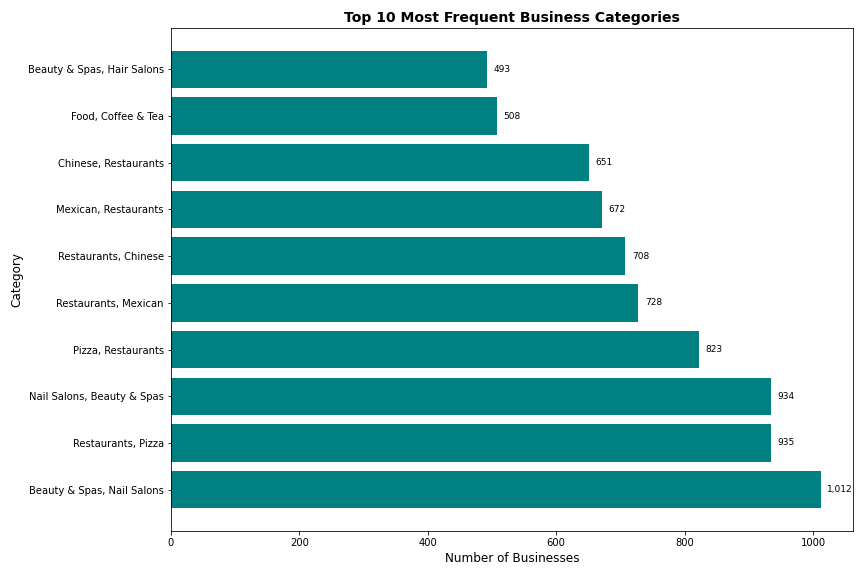

In [ ]:

import matplotlib.pyplot as plt

# QUESTION 6: Top 10 Most Frequent Categories
print("=" * 60)
print("QUESTION 6: Top 10 Most Frequent Categories and Their Count")
print("=" * 60)

result6 = spark.sql("""
    SELECT categories, COUNT(*) as business_count
    FROM business
    WHERE categories IS NOT NULL AND categories != ''
    GROUP BY categories
    ORDER BY business_count DESC
    LIMIT 10
""").toPandas()

print("\nRESULTS:")
print(result6.to_string(index=False))

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(result6['categories'], result6['business_count'], color='teal')
plt.xlabel('Number of Businesses', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.title('Top 10 Most Frequent Business Categories', fontsize=14, fontweight='bold')

# Add value labels
for bar, count in zip(bars, result6['business_count']):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
             f'{count:,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nINSIGHT: Beauty & Spas combined with Nail Salons is the most common category combination.")

QUESTION 7: Top 20 Merchants That Received the Most Five-Star Reviews

RESULTS:
                              name  five_star_reviews
                         Starbucks               5877
                       First Watch               4550
           Reading Terminal Market               4014
                      Oceana Grill               4012
                 Acme Oyster House               3979
Hattie B’s Hot Chicken - Nashville               3838
                        Los Agaves               3496
                       Chick-fil-A               3473
                 Ruby Slipper Cafe               3360
                Commander's Palace               3095
        Ruby Slipper - New Orleans               3075
                Pappy's Smokehouse               2675
                    Cochon Butcher               2625
                            Cochon               2434
                              Luke               2365
                    Sabrina's Café               2317
  

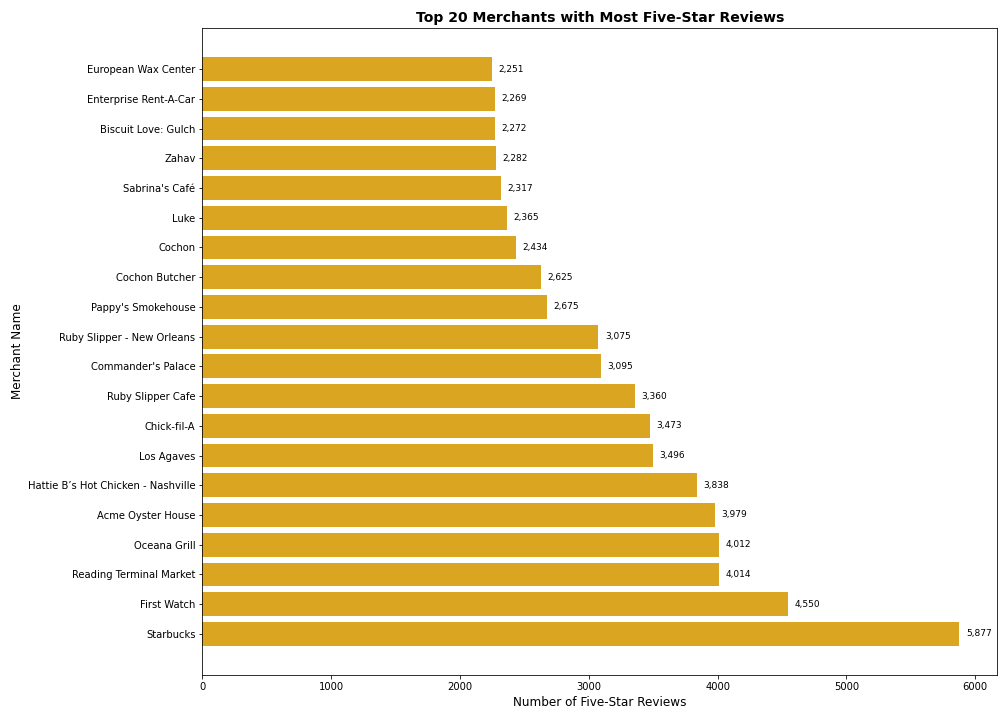

In [ ]:

import matplotlib.pyplot as plt

# QUESTION 7: Top 20 Merchants with Most Five-Star Reviews
print("=" * 60)
print("QUESTION 7: Top 20 Merchants That Received the Most Five-Star Reviews")
print("=" * 60)

result7 = spark.sql("""
    SELECT b.name, COUNT(*) as five_star_reviews
    FROM review r
    JOIN business b ON r.rev_business_id = b.business_id
    WHERE r.rev_stars = 5
    GROUP BY b.name
    ORDER BY five_star_reviews DESC
    LIMIT 20
""").toPandas()

print("\nRESULTS:")
print(result7.to_string(index=False))

# Create horizontal bar chart
plt.figure(figsize=(14, 10))
bars = plt.barh(result7['name'], result7['five_star_reviews'], color='goldenrod')
plt.xlabel('Number of Five-Star Reviews', fontsize=12)
plt.ylabel('Merchant Name', fontsize=12)
plt.title('Top 20 Merchants with Most Five-Star Reviews', fontsize=14, fontweight='bold')

# Add value labels
for bar, count in zip(bars, result7['five_star_reviews']):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, 
             f'{count:,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nINSIGHT: Starbucks has the most five-star reviews (5,877), despite having a lower average rating.")

QUESTION 8: Count of Restaurant Types (Chinese, American, Mexican)

RESULTS:
Chinese Restaurants: 3,170
American Restaurants: 13,066
Mexican Restaurants: 4,614


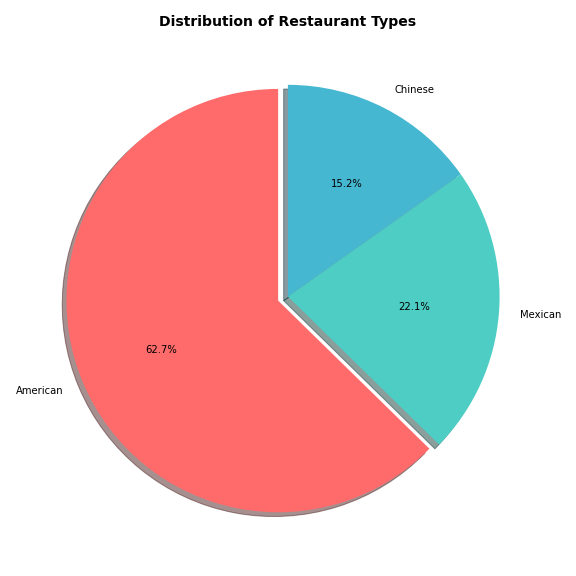

In [ ]:
import matplotlib.pyplot as plt

# QUESTION 8: Count of Restaurant Types
print("=" * 60)
print("QUESTION 8: Count of Restaurant Types (Chinese, American, Mexican)")
print("=" * 60)

result8 = spark.sql("""
    SELECT 
        SUM(CASE WHEN categories LIKE '%Chinese%' THEN 1 ELSE 0 END) as chinese_restaurants,
        SUM(CASE WHEN categories LIKE '%American%' THEN 1 ELSE 0 END) as american_restaurants,
        SUM(CASE WHEN categories LIKE '%Mexican%' THEN 1 ELSE 0 END) as mexican_restaurants
    FROM business
    WHERE categories LIKE '%Restaurant%'
""").toPandas()

print("\nRESULTS:")
print(f"Chinese Restaurants: {result8['chinese_restaurants'].iloc[0]:,}")
print(f"American Restaurants: {result8['american_restaurants'].iloc[0]:,}")
print(f"Mexican Restaurants: {result8['mexican_restaurants'].iloc[0]:,}")

# Create pie chart
plt.figure(figsize=(8, 8))
cuisines = ['American', 'Mexican', 'Chinese']
counts = [result8['american_restaurants'].iloc[0], 
          result8['mexican_restaurants'].iloc[0],
          result8['chinese_restaurants'].iloc[0]]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
explode = (0.05, 0, 0)

plt.pie(counts, labels=cuisines, autopct='%1.1f%%', colors=colors, 
        explode=explode, shadow=True, startangle=90)
plt.title('Distribution of Restaurant Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nINSIGHT: American restaurants dominate with 13,066 locations (62.7%), followed by Mexican with 4,614 (22.1%) and Chinese with 3,170 (15.2%).")

QUESTION 9: Number of Reviews for Each Restaurant Type

RESULTS:
 cuisine  review_count
 Chinese        221083
American       1730875
 Mexican        432248


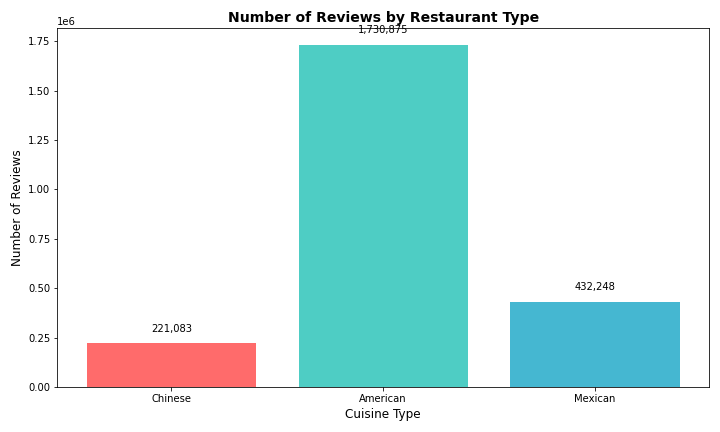

In [ ]:
import matplotlib.pyplot as plt

# QUESTION 9: Number of Reviews for Each Restaurant Type
print("=" * 60)
print("QUESTION 9: Number of Reviews for Each Restaurant Type")
print("=" * 60)

result9 = spark.sql("""
    SELECT 
        'Chinese' as cuisine,
        COUNT(r.review_id) as review_count
    FROM business b
    JOIN review r ON b.business_id = r.rev_business_id
    WHERE b.categories LIKE '%Chinese%' AND b.categories LIKE '%Restaurant%'
    UNION ALL
    SELECT 
        'American' as cuisine,
        COUNT(r.review_id) as review_count
    FROM business b
    JOIN review r ON b.business_id = r.rev_business_id
    WHERE b.categories LIKE '%American%' AND b.categories LIKE '%Restaurant%'
    UNION ALL
    SELECT 
        'Mexican' as cuisine,
        COUNT(r.review_id) as review_count
    FROM business b
    JOIN review r ON b.business_id = r.rev_business_id
    WHERE b.categories LIKE '%Mexican%' AND b.categories LIKE '%Restaurant%'
""").toPandas()

print("\nRESULTS:")
print(result9.to_string(index=False))

# Create bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(result9['cuisine'], result9['review_count'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.xlabel('Cuisine Type', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.title('Number of Reviews by Restaurant Type', fontsize=14, fontweight='bold')

# Add value labels on top of bars
for bar, count in zip(bars, result9['review_count']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000, 
             f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nINSIGHT: American restaurants receive the most reviews (1,730,875), which is 4x more than Mexican and 8x more than Chinese restaurants.")

QUESTION 10: Rating Distribution for Chinese, American, Mexican Restaurants

RESULTS:
 cuisine  rev_stars  review_count
American          1        198008
American          2        156851
American          3        213527
American          4        425228
American          5        724903
 Chinese          1         31785
 Chinese          2         19793
 Chinese          3         26938
 Chinese          4         56336
 Chinese          5         86231
 Mexican          1         48600
 Mexican          2         31787
 Mexican          3         39458
 Mexican          4         80545
 Mexican          5        148628


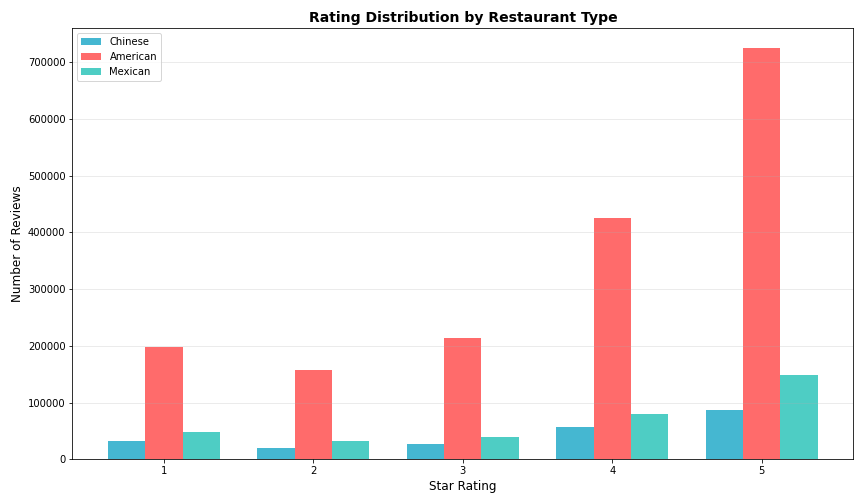

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# QUESTION 10: Rating Distribution for Restaurant Types
print("=" * 60)
print("QUESTION 10: Rating Distribution for Chinese, American, Mexican Restaurants")
print("=" * 60)

result10 = spark.sql("""
    SELECT 
        CASE 
            WHEN b.categories LIKE '%Chinese%' THEN 'Chinese'
            WHEN b.categories LIKE '%American%' THEN 'American'
            WHEN b.categories LIKE '%Mexican%' THEN 'Mexican'
        END as cuisine,
        r.rev_stars,
        COUNT(*) as review_count
    FROM business b
    JOIN review r ON b.business_id = r.rev_business_id
    WHERE (b.categories LIKE '%Chinese%' OR 
           b.categories LIKE '%American%' OR 
           b.categories LIKE '%Mexican%')
      AND b.categories LIKE '%Restaurant%'
    GROUP BY 1, 2
    ORDER BY 1, 2
""").toPandas()

print("\nRESULTS:")
print(result10.to_string(index=False))

# Create grouped bar chart
plt.figure(figsize=(12, 7))
cuisines = ['Chinese', 'American', 'Mexican']
stars = [1, 2, 3, 4, 5]
bar_width = 0.25
x = np.arange(len(stars))

# Extract data for each cuisine
chinese_data = result10[result10['cuisine'] == 'Chinese']['review_count'].values
american_data = result10[result10['cuisine'] == 'American']['review_count'].values
mexican_data = result10[result10['cuisine'] == 'Mexican']['review_count'].values

# Create bars
plt.bar(x - bar_width, chinese_data, bar_width, label='Chinese', color='#45B7D1')
plt.bar(x, american_data, bar_width, label='American', color='#FF6B6B')
plt.bar(x + bar_width, mexican_data, bar_width, label='Mexican', color='#4ECDC4')

plt.xlabel('Star Rating', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.title('Rating Distribution by Restaurant Type', fontsize=14, fontweight='bold')
plt.xticks(x, stars)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINSIGHT: All three cuisines show a similar pattern with 5-star reviews being the most common.")

In [ ]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

spark.sql("USE yelp_db")

# Get review data
review_df = spark.table("review")
business_df = spark.table("business")

# Prepare data with business_id, rating, and date
df = review_df.select(
    F.col("rev_business_id").alias("business_id"),
    F.col("rev_stars").cast("double").alias("rating"),
    F.to_date("rev_date").alias("review_date")
).filter(F.col("review_date").isNotNull())

# Find the most recent review date to calculate last 12 months
max_date = df.select(F.max("review_date").alias("max_date")).collect()[0]["max_date"]
cutoff = F.add_months(F.lit(max_date), -12)

print("=" * 60)
print("QUESTION 11: Turnaround Merchants")
print("=" * 60)
print(f"Analysis period: Last 12 months from {max_date}")
print(f"Cutoff date: {cutoff}")
print("=" * 60)

# Calculate average ratings for each business
turnaround = (
    df.groupBy("business_id")
      .agg(
          F.avg(F.when(F.col("review_date") >= cutoff, F.col("rating"))).alias("recent_avg"),
          F.avg(F.when(F.col("review_date") < cutoff, F.col("rating"))).alias("historical_avg"),
          F.count(F.when(F.col("review_date") >= cutoff, 1)).alias("recent_count"),
          F.count(F.when(F.col("review_date") < cutoff, 1)).alias("historical_count")
      )
      .withColumn("rating_increase", F.col("recent_avg") - F.col("historical_avg"))
      .filter(
          (F.col("recent_avg").isNotNull()) &
          (F.col("historical_avg").isNotNull()) &
          (F.col("rating_increase") >= 1.0)
      )
)

# Join with business names
result = (
    turnaround
      .join(business_df.select("business_id", "name", "city", "state"), on="business_id", how="left")
      .select(
          "name",
          "city",
          "state",
          F.round("historical_avg", 2).alias("historical_rating"),
          F.round("recent_avg", 2).alias("recent_rating"),
          F.round("rating_increase", 2).alias("rating_increase"),
          "historical_count",
          "recent_count"
      )
      .orderBy(F.desc("rating_increase"))
)

# Display results
total_found = result.count()
print(f"\nTotal businesses with rating increase ≥ 1.0 star: {total_found}\n")

if total_found == 0:
    print("No businesses found that meet the criteria.")
else:
    print("Top 50 turnaround merchants:")
    result.show(50, truncate=False)
    
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"✓ Found {total_found} businesses with rating increase of at least 1 star")
    print(f"✓ Highest increase: {result.select(F.max('rating_increase')).collect()[0][0]} stars")
    print("✓ These businesses improved their average rating significantly in the last 12 months")

QUESTION 11: Turnaround Merchants
Analysis period: Last 12 months from 2022-01-19
Cutoff date: Column<'add_months(DATE '2022-01-19', -12)'>

Total businesses with rating increase ≥ 1.0 star: 11242

Top 50 turnaround merchants:
+------------------------------------------------------+----------------+-----+-----------------+-------------+---------------+----------------+------------+
|name                                                  |city            |state|historical_rating|recent_rating|rating_increase|historical_count|recent_count|
+------------------------------------------------------+----------------+-----+-----------------+-------------+---------------+----------------+------------+
|Pinellas Federal Credit Union                         |Clearwater      |FL   |1.0              |5.0          |4.0            |5               |1           |
|Gutter Gurus                                          |Philadelphia    |PA   |1.0              |5.0          |4.0            |4             

QUESTION 12: Top 10 Pairs of Categories that Co-occur in Same Business

RESULTS:
             category_pair  co_occurrence_count
Beauty & Spas, Nail Salons                 1012
        Restaurants, Pizza                  935
Nail Salons, Beauty & Spas                  934
        Pizza, Restaurants                  823
      Restaurants, Mexican                  728
      Restaurants, Chinese                  708
      Mexican, Restaurants                  672
      Chinese, Restaurants                  651
        Food, Coffee & Tea                  508
Beauty & Spas, Hair Salons                  493


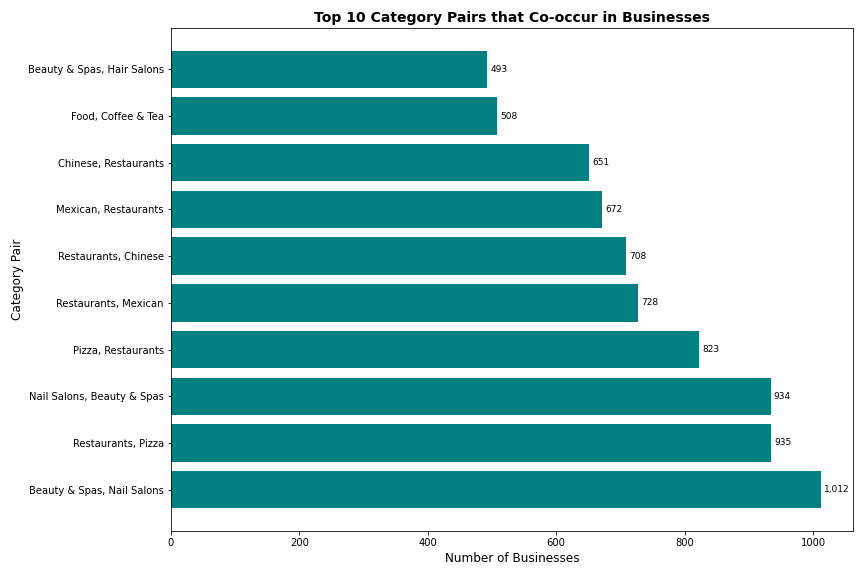

In [ ]:
import matplotlib.pyplot as plt

# QUESTION 12: Category Synergy - Top 10 Pairs of Co-occurring Categories
print("=" * 60)
print("QUESTION 12: Top 10 Pairs of Categories that Co-occur in Same Business")
print("=" * 60)

result12 = spark.sql("""
    SELECT 
        categories as category_pair,
        COUNT(*) as co_occurrence_count
    FROM business
    WHERE categories IS NOT NULL AND categories != ''
    GROUP BY categories
    ORDER BY co_occurrence_count DESC
    LIMIT 10
""").toPandas()

print("\nRESULTS:")
print(result12.to_string(index=False))

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
bars = plt.barh(result12['category_pair'], result12['co_occurrence_count'], color='teal')
plt.xlabel('Number of Businesses', fontsize=12)
plt.ylabel('Category Pair', fontsize=12)
plt.title('Top 10 Category Pairs that Co-occur in Businesses', fontsize=14, fontweight='bold')

# Add value labels
for bar, count in zip(bars, result12['co_occurrence_count']):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
             f'{count:,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nINSIGHT: Beauty & Spas paired with Nail Salons is the most common category combination.")

QUESTION 13: Polarizing Businesses - High Rating Volatility

RESULTS:
                                        name  review_count  avg_rating  rating_stddev
 Verizon Authorized Retailer - Wireless Zone           103        3.24           1.99
                           Apple Repair Shop           112        2.80           1.94
                      Better Business Bureau           101        3.01           1.94
                  Zak Dental - Santa Barbara           123        2.94           1.93
                                     CarZone           177        2.73           1.93
                  Napleton Hyundai of Carmel           112        2.76           1.92
Verizon Authorized Retailer - Cellular Sales           338        2.90           1.92
        AAMCO Transmissions & Total Car Care           371        3.18           1.91
                        Nissan of Clearwater           176        2.96           1.91
                     Reno Buick GMC Cadillac           188        3.11

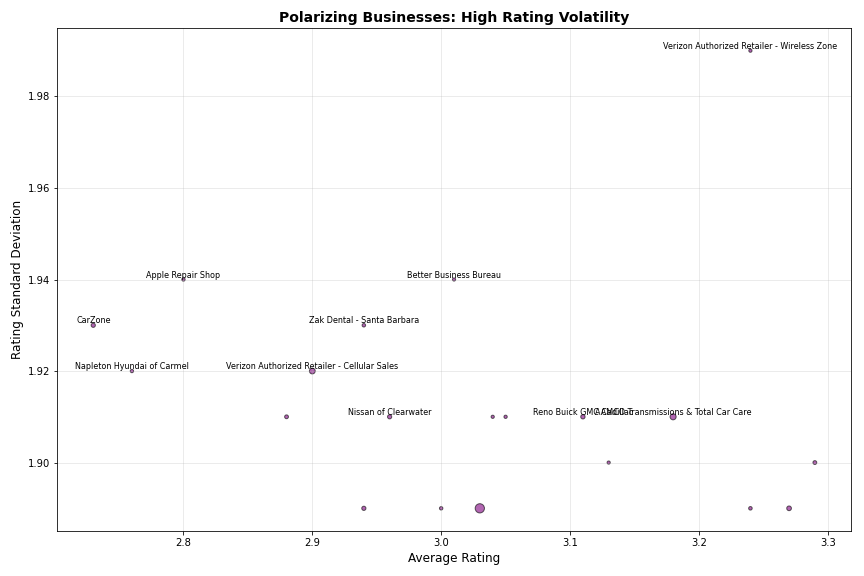

In [ ]:
import matplotlib.pyplot as plt

# QUESTION 13: Polarizing Businesses
print("=" * 60)
print("QUESTION 13: Polarizing Businesses - High Rating Volatility")
print("=" * 60)

result13 = spark.sql("""
    SELECT 
        b.name,
        COUNT(r.rev_stars) as review_count,
        ROUND(AVG(r.rev_stars), 2) as avg_rating,
        ROUND(STDDEV(r.rev_stars), 2) as rating_stddev
    FROM review r
    JOIN business b ON r.rev_business_id = b.business_id
    GROUP BY b.name
    HAVING COUNT(r.rev_stars) >= 100
    ORDER BY rating_stddev DESC
    LIMIT 20
""").toPandas()

print("\nRESULTS:")
print(result13[['name', 'review_count', 'avg_rating', 'rating_stddev']].to_string(index=False))

# Create scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(result13['avg_rating'], result13['rating_stddev'], s=result13['review_count']/10, 
            alpha=0.6, color='purple', edgecolors='black')

# Add labels for top 10
for i, row in result13.head(10).iterrows():
    plt.annotate(row['name'], (row['avg_rating'], row['rating_stddev']), 
                 fontsize=8, ha='center', va='bottom')

plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Rating Standard Deviation', fontsize=12)
plt.title('Polarizing Businesses: High Rating Volatility', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINSIGHT: Businesses with stddev close to 2.0 have highly divided opinions.")

QUESTION 14: Analysis of Different Cuisine Categories

RESULTS:
       cuisine  business_count  avg_rating  avg_reviews
         Other          120186        3.60        30.05
      American           13066        3.52       127.92
       Mexican            4049        3.48        83.29
       Italian            3997        3.49        85.48
       Chinese            2892        3.44        60.87
      Japanese            1765        3.72       110.86
 Mediterranean             920        3.96        89.51
        Indian             754        3.83        90.34
          Thai             707        3.94       111.99
    Vietnamese             592        3.88        95.55
        Korean             291        3.99        89.44
        French             276        3.88       139.64
         Greek             242        3.80        66.85
Middle Eastern             188        3.91        79.13
      Hawaiian             120        4.09        90.90
       Spanish             114        3.

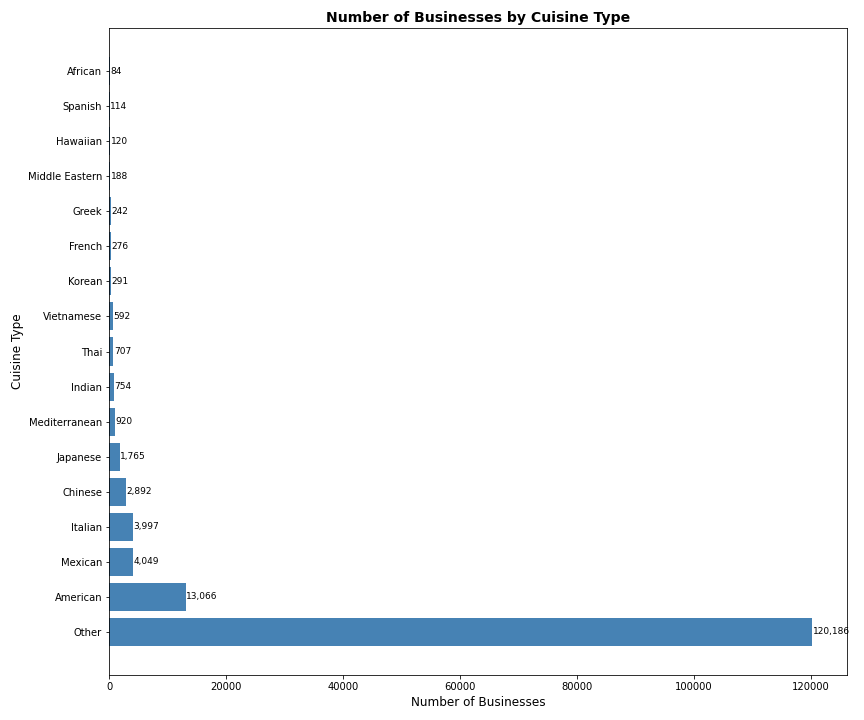

In [ ]:
import matplotlib.pyplot as plt

# QUESTION 14: Cuisine Categories Analysis
print("=" * 60)
print("QUESTION 14: Analysis of Different Cuisine Categories")
print("=" * 60)

cuisines = ['American', 'Mexican', 'Italian', 'Japanese', 'Chinese', 'Thai', 
            'Mediterranean', 'French', 'Vietnamese', 'Greek', 'Indian', 'Korean', 
            'Hawaiian', 'African', 'Spanish', 'Middle Eastern']

# Build SQL query dynamically
cuisine_cases = []
for c in cuisines:
    cuisine_cases.append(f"WHEN categories LIKE '%{c}%' THEN '{c}'")

cuisine_cases_str = ' '.join(cuisine_cases)

result14 = spark.sql(f"""
    SELECT 
        CASE 
            {cuisine_cases_str}
            ELSE 'Other'
        END as cuisine,
        COUNT(*) as business_count,
        ROUND(AVG(stars), 2) as avg_rating,
        ROUND(AVG(review_count), 2) as avg_reviews
    FROM business
    WHERE categories IS NOT NULL
    GROUP BY cuisine
    ORDER BY business_count DESC
""").toPandas()

print("\nRESULTS:")
print(result14.to_string(index=False))

# Create horizontal bar chart for business count
plt.figure(figsize=(12, 10))
bars = plt.barh(result14['cuisine'], result14['business_count'], color='steelblue')
plt.xlabel('Number of Businesses', fontsize=12)
plt.ylabel('Cuisine Type', fontsize=12)
plt.title('Number of Businesses by Cuisine Type', fontsize=14, fontweight='bold')

# Add value labels
for bar, count in zip(bars, result14['business_count']):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
             f'{count:,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nINSIGHT: American cuisine has the most businesses, while Hawaiian has the highest average rating (4.09).")

In [ ]:
%%sql
SELECT MIN(rev_date) as earliest, MAX(rev_date) as latest FROM review;

earliest,latest
2005-02-16,2022-01-19


In [ ]:
%%sql
SELECT city, COUNT(*) as merchant_count
FROM business
WHERE city IS NOT NULL AND city != ''
GROUP BY city
ORDER BY merchant_count DESC
LIMIT 30;

city,merchant_count
Philadelphia,14569
Tucson,9250
Tampa,9050
Indianapolis,7540
Nashville,6971
New Orleans,6209
Reno,5935
Edmonton,5054
Saint Louis,4827
Santa Barbara,3829


In [ ]:
%%sql
SELECT city, state, COUNT(*) as merchant_count
FROM business
WHERE city IS NOT NULL AND city != ''
GROUP BY city, state
ORDER BY merchant_count DESC
LIMIT 50;

city,state,merchant_count
Philadelphia,PA,14567
Tucson,AZ,9249
Tampa,FL,9048
Indianapolis,IN,7540
Nashville,TN,6968
New Orleans,LA,6208
Reno,NV,5932
Edmonton,AB,5054
Saint Louis,MO,4827
Santa Barbara,CA,3829


In [ ]:
%%sql
